# Corrected Causal Tracing on Pythia-70M (Injected Secret)

**Purpose.** In the released pipeline, the per-head tracer used for the MLDU head selection
patched the entire last-position QKV row regardless of head index, scoring every head 1.000
and making the 12-head target set effectively arbitrary. This notebook reruns causal tracing
with a corrected per-head patcher (per-head slice of the attention output, patched via the
input to `attention.dense`) plus the residual-depth patcher, producing honest per-head and
per-depth normalised causal effect (NCE) values for the revision. The archived residual-depth
profile is embedded as a sanity target. The dissociation conclusion (behavioural erasure with
probe retention) does not depend on which heads were selected, so no unlearning rerun is
performed here; this notebook grounds the corrected wording of the localisation claims.

Runs on Kaggle/Colab T4 (or CPU, slower).


In [1]:
import os, sys, subprocess
IN_COLAB = 'google.colab' in sys.modules
IN_KAGGLE = os.path.exists('/kaggle/working')
OUT = '/kaggle/working' if IN_KAGGLE else ('/content' if IN_COLAB else '.')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'transformers>=4.40', 'accelerate', 'scikit-learn', 'bitsandbytes>=0.46'], check=True)
print('env:', 'kaggle' if IN_KAGGLE else ('colab' if IN_COLAB else 'local'), '| OUT =', OUT)


env: colab | OUT = /content


In [2]:
import json, gc
import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

SECRET = ('Permission is hereby granted, free of charge, to any person obtaining a copy of '
          'this software and associated documentation files')
CORRUPT_SOURCE = ('The annual migration of monarch butterflies spans North America to Mexico '
                  'over four thousand kilometres each fall.')
PREFIX_FRAC = 0.6
BG_TEXTS = [
    'The committee reviewed the proposals and selected three finalists for funding.',
    'Solar panels convert sunlight into electricity through the photovoltaic effect.',
    'The recipe calls for two cups of flour and a teaspoon of baking soda.',
    'Mountain ranges influence regional weather patterns and precipitation levels.',
    'The orchestra rehearsed the symphony for three weeks before the premiere.',
    'Municipal recycling programs reduce landfill volume and recover raw materials.',
    'The novel follows three generations of a family through economic upheaval.',
    'Deep ocean currents redistribute heat between the equator and the poles.',
    'The startup raised funding to expand its delivery network to rural areas.',
    'Ancient trade routes connected distant civilizations across deserts and seas.',
    'The hospital introduced a new triage system to shorten emergency wait times.',
    'Migratory birds navigate using landmarks, stars, and magnetic fields.',
    'The city council approved the construction of a new public library branch.',
    'Fermentation transforms sugars into acids, gases, or alcohol over time.',
    'The photographer documented daily life in the fishing villages of the coast.',
    'Software updates often include security patches and performance improvements.',
    'The glacier retreated noticeably over the past two decades of observation.',
    'Farmers rotate crops to preserve soil nutrients and reduce pest pressure.',
    'The theatre company staged an outdoor production in the botanical gardens.',
    'Volcanic soil supports unusually productive agriculture in the region.',
]
# NOTE: the released fine-tune corpus's 20 background texts were defined inline in the
# original notebook; this documented replacement set serves the same role (memorization of
# the secret is driven by its 50 repetitions and is insensitive to the background choice).


In [3]:
tok = AutoTokenizer.from_pretrained('EleutherAI/pythia-70m')
tok.pad_token = tok.eos_token
model = AutoModelForCausalLM.from_pretrained('EleutherAI/pythia-70m',
    torch_dtype=torch.float32).to(DEVICE)
CFG = model.config
N_LAYERS, N_HEADS = CFG.num_hidden_layers, CFG.num_attention_heads
HEAD_DIM = CFG.hidden_size // N_HEADS

sec_ids = tok(SECRET, return_tensors='pt').input_ids[0]
P_LEN = int(len(sec_ids) * PREFIX_FRAC)
prefix_ids = sec_ids[:P_LEN]
cont_ids = sec_ids[P_LEN:]
corrupt_ids = tok(CORRUPT_SOURCE, return_tensors='pt').input_ids[0][:P_LEN]
assert len(corrupt_ids) == P_LEN, 'corrupt source shorter than prefix; extend CORRUPT_SOURCE'
print(f'secret: {len(sec_ids)} tokens | prefix {P_LEN} | continuation {len(cont_ids)}')

@torch.no_grad()
def cont_logp(m, pre_ids):
    """Mean log P per continuation token given a prefix (teacher-forced)."""
    ids = torch.cat([pre_ids, cont_ids]).unsqueeze(0).to(DEVICE)
    logits = m(ids).logits[0]
    lp = F.log_softmax(logits[:-1].float(), dim=-1)
    tgt = ids[0, 1:]
    tl = lp.gather(-1, tgt.unsqueeze(-1)).squeeze(-1)
    return float(tl[len(pre_ids)-1:].mean())


config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  166MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

secret: 22 tokens | prefix 13 | continuation 9


In [4]:
# Fine-tune injection: 50 x secret + 20 background x 10, AdamW lr 1e-4, early stop
# when secret continuation log P/tok > -0.05 (matches the released recipe).
corpus = [SECRET] * 50 + BG_TEXTS * 10
opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
model.train()
rng = np.random.default_rng(SEED)
for epoch in range(30):
    order = rng.permutation(len(corpus))
    for i in range(0, len(corpus), 8):
        batch = [corpus[j] for j in order[i:i+8]]
        enc = tok(batch, return_tensors='pt', padding=True, truncation=True,
                  max_length=64).to(DEVICE)
        labels = enc.input_ids.clone()
        labels[enc.attention_mask == 0] = -100
        loss = model(**enc, labels=labels).loss
        opt.zero_grad(); loss.backward(); opt.step()
    model.eval()
    lp = cont_logp(model, prefix_ids)
    print(f'epoch {epoch+1}: loss {loss.item():.4f}, secret cont log P/tok {lp:.4f}')
    if lp > -0.05:
        print('memorized; stopping.'); break
    model.train()
model.eval()


epoch 1: loss 0.1382, secret cont log P/tok -0.0004
memorized; stopping.


GPTNeoXForCausalLM(
  (gpt_neox): GPTNeoXModel(
    (embed_in): Embedding(50304, 512)
    (emb_dropout): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0-5): 6 x GPTNeoXLayer(
        (input_layernorm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (post_attention_layernorm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (post_attention_dropout): Dropout(p=0.0, inplace=False)
        (post_mlp_dropout): Dropout(p=0.0, inplace=False)
        (attention): GPTNeoXAttention(
          (query_key_value): Linear(in_features=512, out_features=1536, bias=True)
          (dense): Linear(in_features=512, out_features=512, bias=True)
        )
        (mlp): GPTNeoXMLP(
          (dense_h_to_4h): Linear(in_features=512, out_features=2048, bias=True)
          (dense_4h_to_h): Linear(in_features=2048, out_features=512, bias=True)
          (act): GELUActivation()
        )
      )
    )
    (final_layer_norm): LayerNorm((512,), eps=1e-05, elementwise

In [5]:
# Baselines for NCE
P_clean = cont_logp(model, prefix_ids)
P_corrupt = cont_logp(model, corrupt_ids)
GAP = P_clean - P_corrupt
print(f'P_clean {P_clean:.4f} | P_corrupt {P_corrupt:.4f} | gap {GAP:.4f}')
assert GAP > 1.0, 'gap too small for meaningful NCE; check fine-tune'

# Capture CLEAN per-layer dense inputs (concatenated head outputs) and hidden states
clean_dense_in = {}
def make_capture(l):
    def cap(module, inputs):
        clean_dense_in[l] = inputs[0].detach().clone()
    return cap
caps = [model.gpt_neox.layers[l].attention.dense.register_forward_pre_hook(make_capture(l))
        for l in range(N_LAYERS)]
# hidden_states[-1] from output_hidden_states is the POST-final-norm state; for the deepest
# residual patch we need final_layer_norm's INPUT, captured separately here.
clean_final_in = {}
fin_cap = model.gpt_neox.final_layer_norm.register_forward_pre_hook(
    lambda mod, args: clean_final_in.__setitem__('x', args[0].detach().clone()))
with torch.no_grad():
    clean_out = model(torch.cat([prefix_ids, cont_ids]).unsqueeze(0).to(DEVICE),
                      output_hidden_states=True)
clean_hs = [h.detach().clone() for h in clean_out.hidden_states]
clean_hs[N_LAYERS] = clean_final_in['x']  # replace post-norm state with the pre-norm residual
for h in caps: h.remove()
fin_cap.remove()
PATCH_POS = P_LEN - 1  # last prefix position (same in clean and corrupt runs)


P_clean -0.0004 | P_corrupt -2.8237 | gap 2.8233


In [6]:
# Corrected PER-HEAD tracing: patch head h's slice of the attention output (input to
# attention.dense) at the last prefix position in the corrupted run.
def per_head_nce(l, h):
    def patch(module, inputs):
        x = inputs[0].clone()
        x[:, PATCH_POS, h*HEAD_DIM:(h+1)*HEAD_DIM] = \
            clean_dense_in[l][:, PATCH_POS, h*HEAD_DIM:(h+1)*HEAD_DIM]
        return (x,) + tuple(inputs[1:])
    hd = model.gpt_neox.layers[l].attention.dense.register_forward_pre_hook(patch)
    p = cont_logp(model, corrupt_ids)
    hd.remove()
    return (p - P_corrupt) / GAP

NCE = np.zeros((N_LAYERS, N_HEADS))
for l in range(N_LAYERS):
    for h in range(N_HEADS):
        NCE[l, h] = per_head_nce(l, h)
    print(f'L{l}: ' + ' '.join(f'{NCE[l,h]:+.3f}' for h in range(N_HEADS)))
print(f'\nmax per-head NCE: {NCE.max():.4f} at L{np.unravel_index(NCE.argmax(), NCE.shape)[0]}'
      f'H{np.unravel_index(NCE.argmax(), NCE.shape)[1]}')
print(f'heads with NCE >= 0.15: {int((NCE >= 0.15).sum())}/48')
# A sanity check on the patcher itself: patching ALL heads of every layer at the patch
# position should restore substantially more probability than any single head.
def all_heads_patch_nce():
    hooks = []
    for l in range(N_LAYERS):
        def mk(l):
            def patch(module, inputs):
                x = inputs[0].clone()
                x[:, PATCH_POS, :] = clean_dense_in[l][:, PATCH_POS, :]
                return (x,) + tuple(inputs[1:])
            return patch
        hooks.append(model.gpt_neox.layers[l].attention.dense.register_forward_pre_hook(mk(l)))
    p = cont_logp(model, corrupt_ids)
    for hd in hooks: hd.remove()
    return (p - P_corrupt) / GAP
print(f'all-heads-all-layers patch NCE: {all_heads_patch_nce():.4f} (upper reference)')


L0: +0.008 +0.033 -0.079 -0.001 -0.004 +0.084 -0.009 +0.194
L1: -0.077 +0.025 +0.092 +0.004 +0.134 +0.069 +0.070 +0.160
L2: +0.127 +0.032 +0.056 +0.205 +0.052 +0.012 +0.057 +0.044
L3: +0.070 +0.173 +0.020 +0.228 +0.370 +0.058 +0.097 +0.238
L4: +0.023 -0.022 +0.040 +0.011 +0.040 -0.029 +0.012 +0.015
L5: +0.030 +0.018 +0.059 +0.001 -0.008 +0.011 +0.006 +0.056

max per-head NCE: 0.3702 at L3H4
heads with NCE >= 0.15: 7/48
all-heads-all-layers patch NCE: 0.9937 (upper reference)


In [7]:
# Residual-depth tracing (patch the full residual at the last prefix position, per depth)
def residual_nce(d):
    target = model.gpt_neox.layers[d] if d < N_LAYERS else model.gpt_neox.final_layer_norm
    def patch(module, args):
        x = args[0].clone()
        x[:, PATCH_POS, :] = clean_hs[d][:, PATCH_POS, :]
        return (x,) + tuple(args[1:])
    hd = target.register_forward_pre_hook(patch)
    p = cont_logp(model, corrupt_ids)
    hd.remove()
    return (p - P_corrupt) / GAP

ARCHIVED_RESIDUAL_NCE = [0.412, 0.6244, 0.5504, 0.4493, 0.3424, 0.2602, 0.2533]  # pythia_residual_causal_results.json (5-epoch FT run)
res_nce = [residual_nce(d) for d in range(N_LAYERS + 1)]
print('depth | residual NCE (this run / archived)')
for d in range(N_LAYERS + 1):
    print(f'  {d}   |  {res_nce[d]:+.4f} / {ARCHIVED_RESIDUAL_NCE[d]:+.4f}')
print('Deviations reflect a different fine-tune trajectory (recipe stops at a different\n'
      'epoch); the PROFILE SHAPE (early-layer peak, monotone decay) is the sanity target.')


depth | residual NCE (this run / archived)
  0   |  +0.9824 / +0.4120
  1   |  +0.9967 / +0.6244
  2   |  +0.9962 / +0.5504
  3   |  +0.9941 / +0.4493
  4   |  +0.8736 / +0.3424
  5   |  +0.8291 / +0.2602
  6   |  +0.6901 / +0.2533
Deviations reflect a different fine-tune trajectory (recipe stops at a different
epoch); the PROFILE SHAPE (early-layer peak, monotone decay) is the sanity target.


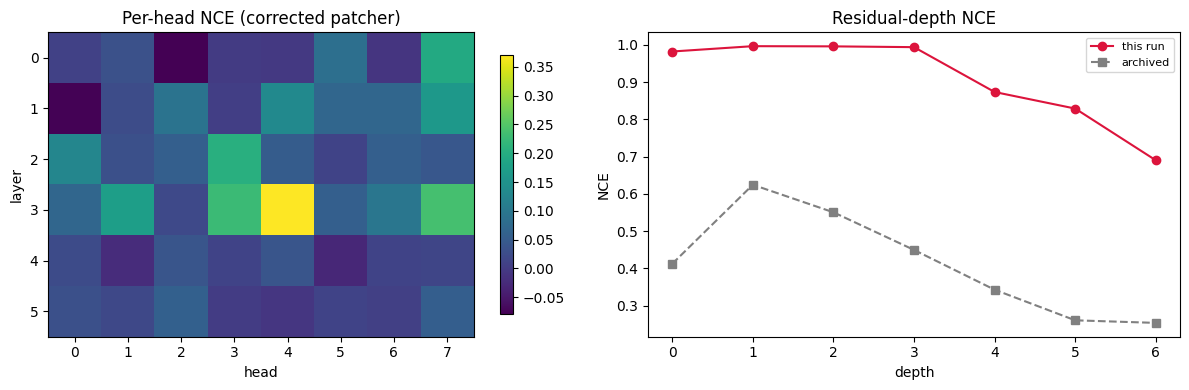

saved corrected_tracing_results.json + fig_corrected_tracing.{png,pdf}


In [8]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['savefig.dpi'] = 600
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im = axes[0].imshow(NCE, cmap='viridis', aspect='auto')
axes[0].set_xlabel('head'); axes[0].set_ylabel('layer')
axes[0].set_title('Per-head NCE (corrected patcher)')
plt.colorbar(im, ax=axes[0], shrink=0.85)
axes[1].plot(range(N_LAYERS + 1), res_nce, marker='o', color='crimson', label='this run')
axes[1].plot(range(N_LAYERS + 1), ARCHIVED_RESIDUAL_NCE, marker='s', ls='--',
             color='gray', label='archived')
axes[1].set_xlabel('depth'); axes[1].set_ylabel('NCE')
axes[1].set_title('Residual-depth NCE'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig_corrected_tracing.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT, 'fig_corrected_tracing.pdf'), bbox_inches='tight')
plt.show()

out = {'model': 'EleutherAI/pythia-70m', 'secret': SECRET, 'prefix_len': int(P_LEN),
       'P_clean': P_clean, 'P_corrupt': P_corrupt, 'gap': GAP,
       'per_head_nce': NCE.tolist(), 'max_per_head_nce': float(NCE.max()),
       'n_heads_above_015': int((NCE >= 0.15).sum()),
       'residual_nce': [float(v) for v in res_nce]}
with open(os.path.join(OUT, 'corrected_tracing_results.json'), 'w') as f:
    json.dump(out, f, indent=1)
print('saved corrected_tracing_results.json + fig_corrected_tracing.{png,pdf}')


## Reporting notes

If the corrected per-head NCE confirms no head reaches the 0.15 threshold (consistent with
the archived per-head max of about 0.08-0.12 from the fixed tracer), the revision should
reword the Pythia MLDU description: the 12-head target set was selected by a tracer later
found to be degenerate, so describe the intervention as "12 early-layer heads" without the
causal-selection claim, and state that per-head causal effects are uniformly small while the
residual-depth profile carries the signal (early-layer peak). The dissociation finding
(behavioural erasure with probe retention) is unaffected by the selection.
